# VULCAN-JAX Quickstart

Install:
```
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ vulcan-jax
```

In [1]:
import vulcan_jax

print("vulcan-jax version:", vulcan_jax.__version__)

vulcan-jax version: 0.1.1


## Run HD189733b with default settings

The default config ships with the package -- atmosphere, network, and photo cross-sections are all included.

In [2]:
# Create a config with a short run (10 steps) for demonstration
cfg = vulcan_jax.make_config(
    count_max=10,
    count_min=1,
    use_print_prog=False,
    use_live_plot=False,
    use_live_flux=False,
)

In [3]:
# Build the initial state (atmosphere, rates, initial abundances, photo cross-sections)
rs = vulcan_jax.RunState.with_pre_loop_setup(cfg)

Constant extension is used.
Using special form for the reaction: OH + CH3 + M -> CH3OH + M
Initializing with the default solar abundance.
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Neglected!
Element # from element abundance file not found in element data file. Neglected!
Element # for setting abundances not found. Ne

In [4]:
import numpy as np

# Inspect the state
print("Pressure grid (bar):", np.asarray(rs.atm.pco) / 1e6)
print("Temperature range:", float(rs.atm.Tco.min()), "-", float(rs.atm.Tco.max()), "K")
print("Number of layers:", rs.atm.Tco.shape[0])
print("Number of species:", rs.step.y.shape[1])
print("Species list:", vulcan_jax.chem_funs.spec_list[:10], "...")

Pressure grid (bar): [1.00000000e+03 8.43673672e+02 7.11785265e+02 6.00514488e+02
 5.06638264e+02 4.27437364e+02 3.60617651e+02 3.04243618e+02
 2.56682330e+02 2.16556124e+02 1.82702700e+02 1.54141458e+02
 1.30045090e+02 1.09715619e+02 9.25641789e+01 7.80939607e+01
 6.58858186e+01 5.55861305e+01 4.68965549e+01 3.95653887e+01
 3.33802767e+01 2.81620607e+01 2.37595891e+01 2.00453398e+01
 1.69117254e+01 1.42679775e+01 1.20375170e+01 1.01557362e+01
 8.56812721e+00 7.22870335e+00 6.09866670e+00 5.14528453e+00
 4.34094109e+00 3.66233771e+00 3.08981791e+00 2.60679802e+00
 2.19928686e+00 1.85548042e+00 1.56541998e+00 1.32070362e+00
 1.11424288e+00 9.40057378e-01 7.93101660e-01 6.69118990e-01
 5.64518076e-01 4.76269038e-01 4.01815648e-01 3.39001283e-01
 2.86006458e-01 2.41296118e-01 2.03575182e-01 1.71751022e-01
 1.44901815e-01 1.22249846e-01 1.03138977e-01 8.70156393e-02
 7.34128040e-02 6.19364499e-02 5.22541521e-02 4.40854524e-02
 3.71937355e-02 3.13793754e-02 2.64739529e-02 2.23353771e-02
 1.

## Plot volume mixing ratios

A standard atmospheric chemistry diagnostic: VMR profiles for key species vs pressure.

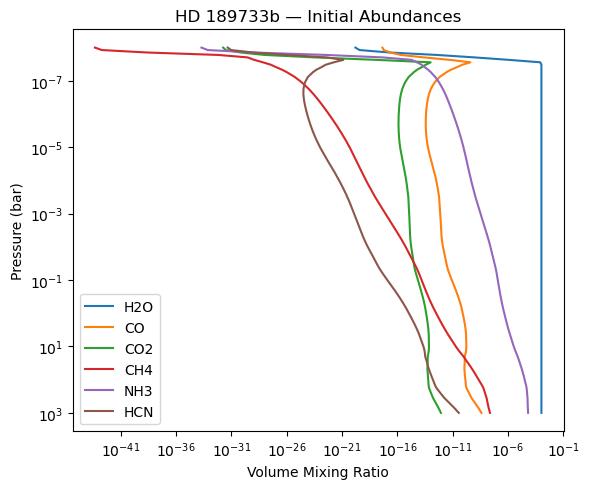

In [5]:
import matplotlib.pyplot as plt

species_to_plot = ["H2O", "CO", "CO2", "CH4", "NH3", "HCN"]
spec_list = vulcan_jax.chem_funs.spec_list

pressure_bar = np.asarray(rs.atm.pco) / 1e6
ymix = np.asarray(rs.step.ymix)

fig, ax = plt.subplots(figsize=(6, 5))
for sp in species_to_plot:
    idx = spec_list.index(sp)
    ax.plot(ymix[:, idx], pressure_bar, label=sp)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Volume Mixing Ratio")
ax.set_ylabel("Pressure (bar)")
ax.set_title("HD 189733b — Initial Abundances")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Access individual modules

All VULCAN-JAX modules are importable under the `vulcan_jax` namespace.

In [6]:
from vulcan_jax import chem_funs

print("Network:", chem_funs.ni, "species,", chem_funs.nr, "reactions")
print("First 10 species:", chem_funs.spec_list[:10])

Network: 69 species, 878 reactions
First 10 species: ['OH', 'H2', 'H2O', 'H', 'O', 'CH', 'C', 'CH2', 'CH3', 'CH4']
